# 06-Unlabeled Performance Estimation (NannyML)

In Lesson 05, we used Evidently AI to measure statistical Data Drift and Concept Drift across input feature distributions. Detecting that input distributions have shifted is critical, but it leaves an urgent operational question unanswered: **How much has the model's actual predictive performance degraded right now?**

In enterprise production environments, true ground-truth labels ($Y$) are rarely available immediately:

* **Credit Risk:** A model predicts loan default today, but actual default labels take $12\text{--}36\text{ months}$ to observe.
* **Fraud Detection:** A fraudulent transaction occurs today, but chargeback labels arrive $30\text{--}90\text{ days}$ later.
* **Customer Churn:** Churn status is only confirmed at the end of a quarterly or annual subscription cycle.

If you wait for ground-truth labels to calculate accuracy, ROC-AUC, or F1 score, you are measuring historical damage long after business losses have occurred. To monitor real-time health, we must estimate model performance on **unlabeled production data**.

In this module, we will dissect **Confidence-Based Performance Estimation (CBPE)**, implement **NannyML** to estimate ROC-AUC and F1 scores without ground-truth labels, and establish automated alert thresholds to catch performance drops in real time.

## 1. The Mathematics of Confidence-Based Performance Estimation (CBPE)

### Probability Calibration

CBPE relies on the fundamental assumption that a model's output probability $\hat{p}_i = P(Y_i = 1 \mid X_i)$ is **well-calibrated**. A model is perfectly calibrated if, among all predictions where it assigns a confidence score of $0.80$, exactly $80\%$ of those instances belong to the positive class ($Y = 1$):


$$P(Y_i = 1 \mid \hat{p}_i = s) = s$$

If probabilities are uncalibrated (e.g., raw SVM outputs or overconfident uncalibrated Neural Networks), they must first be calibrated on validation data using **Isotonic Regression** or **Platt Scaling** before CBPE can be applied.

### Expected Confusion Matrix

Suppose we deploy a binary classification model to an unlabeled production batch of $N$ instances. For a given decision threshold $T \in [0, 1]$, instance $i$ receives a predicted binary class $\hat{y}_i = \mathbb{I}(\hat{p}_i \ge T)$.

Because we do not possess true labels $Y_i$, we cannot count true positives directly. Instead, we compute the **Expected Confusion Matrix** by treating the calibrated probability $\hat{p}_i$ as the probability that $Y_i = 1$:

$$\mathbb{E}[\text{TP}] = \sum_{i: \hat{y}_i = 1} \hat{p}_i$$

$$\mathbb{E}[\text{FP}] = \sum_{i: \hat{y}_i = 1} (1 - \hat{p}_i)$$

$$\mathbb{E}[\text{FN}] = \sum_{i: \hat{y}_i = 0} \hat{p}_i$$

$$\mathbb{E}[\text{TN}] = \sum_{i: \hat{y}_i = 0} (1 - \hat{p}_i)$$

### Deriving Estimated Performance Metrics

Using these expected values, we derive non-parametric estimates for standard performance metrics over any chunk of unlabeled production data:

$$\widehat{\text{Precision}} = \frac{\mathbb{E}[\text{TP}]}{\mathbb{E}[\text{TP}] + \mathbb{E}[\text{FP}]} = \frac{\sum_{i: \hat{y}_i = 1} \hat{p}_i}{\sum_{i: \hat{y}_i = 1} 1}$$

$$\widehat{\text{Recall}} = \frac{\mathbb{E}[\text{TP}]}{\mathbb{E}[\text{TP}] + \mathbb{E}[\text{FN}]} = \frac{\sum_{i: \hat{y}_i = 1} \hat{p}_i}{\sum_{i=1}^N \hat{p}_i}$$

$$\widehat{\text{F1}} = \frac{2 \cdot \mathbb{E}[\text{TP}]}{2 \cdot \mathbb{E}[\text{TP}] + \mathbb{E}[\text{FP}] + \mathbb{E}[\text{FN}]}$$

To estimate **ROC-AUC**, CBPE evaluates $\mathbb{E}[\text{TP}]$ and $\mathbb{E}[\text{FP}]$ across a continuum of decision thresholds $T \in [0, 1]$, constructing an estimated ROC curve and integrating the area underneath.

### Direct Loss Estimation (DLE) for Regression

For continuous regression targets ($Y \in \mathbb{R}$), CBPE cannot be used directly because there are no discrete class probabilities. Instead, NannyML uses **Direct Loss Estimation (DLE)**: an auxiliary machine learning model $\hat{g}(X)$ is trained specifically to predict the absolute error $\vert{}y_i - \hat{y}_i\vert{}$ of the primary model using input features $X$.

---

## 2. Imperative Execution: Estimating Performance with NannyML

Let's build a programmatic, local performance estimation workflow using Python and NannyML. We will simulate a baseline reference dataset (with ground truth) and an unlabeled production analysis stream where feature drift causes performance degradation.

In [11]:
# Required installations: pip install nannyml pandas numpy scikit-learn
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import nannyml as nml

print("--- 🚀 Initializing NannyML Performance Estimation Sandbox ---")

# 1. 📝 Synthetic Data Generation
np.random.seed(42)
X_raw, y_raw = make_classification(
    n_samples=6000, n_features=10, n_informative=8, 
    n_redundant=2, random_state=42
)

# Split into Reference (Validation/Baseline) and Analysis (Unlabeled Production Stream)
X_ref, y_ref = X_raw[:3000], y_raw[:3000]
X_ana, y_ana = X_raw[3000:], y_raw[3000:]

# 2. 🧠 Train and Calibrate the Primary Model
base_model = RandomForestClassifier(n_estimators=50, random_state=42)
# Ensure outputs are well-calibrated via CalibratedClassifierCV
calibrated_model = CalibratedClassifierCV(estimator=base_model, method='sigmoid', cv=3)
calibrated_model.fit(X_ref, y_ref)

# 3. 📦 Construct Reference DataFrame
ref_probs = calibrated_model.predict_proba(X_ref)[:, 1]
ref_preds = calibrated_model.predict(X_ref)

df_reference = pd.DataFrame(X_ref, columns=[f'feat_{i}' for i in range(10)])
df_reference['y_pred_proba'] = ref_probs
df_reference['y_pred'] = ref_preds
df_reference['y_true'] = y_ref
df_reference['timestamp'] = pd.date_range(start='2026-01-01', periods=3000, freq='h')

# 4. 🧨 Construct Analysis DataFrame (Simulating Drift in Chunks 3-6)
# Introduce synthetic noise/covariate shift in the latter half of the analysis stream
X_ana_drifted = X_ana.copy()
X_ana_drifted[1500:, :5] += np.random.normal(loc=2.5, scale=1.5, size=(1500, 5))

ana_probs = calibrated_model.predict_proba(X_ana_drifted)[:, 1]
ana_preds = calibrated_model.predict(X_ana_drifted)

df_analysis = pd.DataFrame(X_ana_drifted, columns=[f'feat_{i}' for i in range(10)])
df_analysis['y_pred_proba'] = ana_probs
df_analysis['y_pred'] = ana_preds
# Notice: In real production, 'y_true' is NOT available!
df_analysis['y_true'] = np.nan 
df_analysis['timestamp'] = pd.date_range(start='2026-05-06', periods=3000, freq='h')

print("\n--- 🧮 Executing NannyML CBPE Estimator Engine ---")

# 5. Initialize CBPE Estimator
estimator = nml.CBPE(
    problem_type='classification_binary',
    y_pred_proba='y_pred_proba',
    y_pred='y_pred',
    y_true='y_true',
    metrics=['roc_auc', 'f1'],
    chunk_size=500, # Process in chunks of 500 predictions
    timestamp_column_name='timestamp'
)

# Fit CBPE on the Reference dataset (Establishes calibration bounds and thresholds)
estimator.fit(df_reference)

# Estimate performance on the Unlabeled Analysis Stream
estimated_results = estimator.estimate(df_analysis)
df_estimates = estimated_results.to_df()
df_estimates.head()
print("   ✅ Estimation Matrix Execution Complete.")
display(
    df_estimates[
        [
            ('chunk', 'chunk_index'),
            ('chunk', 'start_date'),
            ('roc_auc', 'value'),
            ('f1', 'value'),
            ('roc_auc', 'alert'),
            ('f1', 'alert'),
        ]
    ].head(6)
)

--- 🚀 Initializing NannyML Performance Estimation Sandbox ---

--- 🧮 Executing NannyML CBPE Estimator Engine ---
   ✅ Estimation Matrix Execution Complete.


chunk                       roc_auc        f1 roc_auc    f1
  chunk_index          start_date     value     value   alert alert
0           0 2026-01-01 00:00:00  0.969242  0.930745    True  True
1           1 2026-01-21 20:00:00  0.969317  0.929997    True  True
2           2 2026-02-11 16:00:00  0.968280  0.926599    True  True
3           3 2026-03-04 12:00:00  0.970955  0.933114    True  True
4           4 2026-03-25 08:00:00  0.969952  0.934989    True  True
5           5 2026-04-15 04:00:00  0.968412  0.928033    True  True

## 3. Declarative Execution: Automated Thresholding & SLA Alerts

In production MLOps, we extract confidence intervals and alerts directly from the CBPE metric object. NannyML automatically computes upper and lower control limits ($\pm 3\sigma$) based on reference baseline variance.

When estimated performance breaches lower control limits, an alert is raised to flag operational risk.

In [12]:
print("\n--- ⚡ Parsing CBPE Performance Alerts ---")

# Extract detailed metric results for ROC-AUC
roc_auc_results = estimated_results.filter(metrics=['roc_auc']).to_df()

# Flatten multi-index columns for easy operational parsing
roc_auc_results.columns = ['_'.join(col).strip('_') for col in roc_auc_results.columns]

# Display key telemetry metrics for each chunk
print("Chunk-Level Estimated ROC-AUC Telemetry:")
for idx, row in roc_auc_results.iterrows():
    chunk_name = row['chunk_key']
    est_value = row['roc_auc_value']
    lower_threshold = row['roc_auc_lower_threshold']
    alert_flag = row['roc_auc_alert']
    
    status = "🚨 ALERT: Performance Drop" if alert_flag else "✅ Healthy"
    print(f"   -> Chunk: {chunk_name} | Est. ROC-AUC: {est_value:.4f} | Lower SLA: {lower_threshold:.4f} | Status: {status}")

# Evaluate total alerts
total_alerts = roc_auc_results['roc_auc_alert'].sum()
if total_alerts > 0:
    print(f"\n❌ ACTION REQUIRED: {total_alerts} chunks breached lower control limits.")
    print("   Triggering automated alert to On-Call MLOps Engineer via Alertmanager webhook.")
else:
    print("\n✅ SYSTEM HEALTHY: All estimated metrics remain within confidence bounds.")


--- ⚡ Parsing CBPE Performance Alerts ---
Chunk-Level Estimated ROC-AUC Telemetry:
   -> Chunk: [0:499] | Est. ROC-AUC: 0.9692 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performance Drop
   -> Chunk: [500:999] | Est. ROC-AUC: 0.9693 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performance Drop
   -> Chunk: [1000:1499] | Est. ROC-AUC: 0.9683 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performance Drop
   -> Chunk: [1500:1999] | Est. ROC-AUC: 0.9710 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performance Drop
   -> Chunk: [2000:2499] | Est. ROC-AUC: 0.9700 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performance Drop
   -> Chunk: [2500:2999] | Est. ROC-AUC: 0.9684 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performance Drop
   -> Chunk: [0:499] | Est. ROC-AUC: 0.9520 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performance Drop
   -> Chunk: [500:999] | Est. ROC-AUC: 0.9542 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performance Drop
   -> Chunk: [1000:1499] | Est. ROC-AUC: 0.9519 | Lower SLA: 0.9999 | Status: 🚨 ALERT: Performan

## 4. Visualizing Estimated vs. Realized Metric Trajectories

To understand how CBPE behaves when ground-truth labels eventually arrive (delayed realization), let's plot the **Estimated Performance** against **Alert Thresholds** and the **Realized Ground-Truth Performance** using Matplotlib and Seaborn.

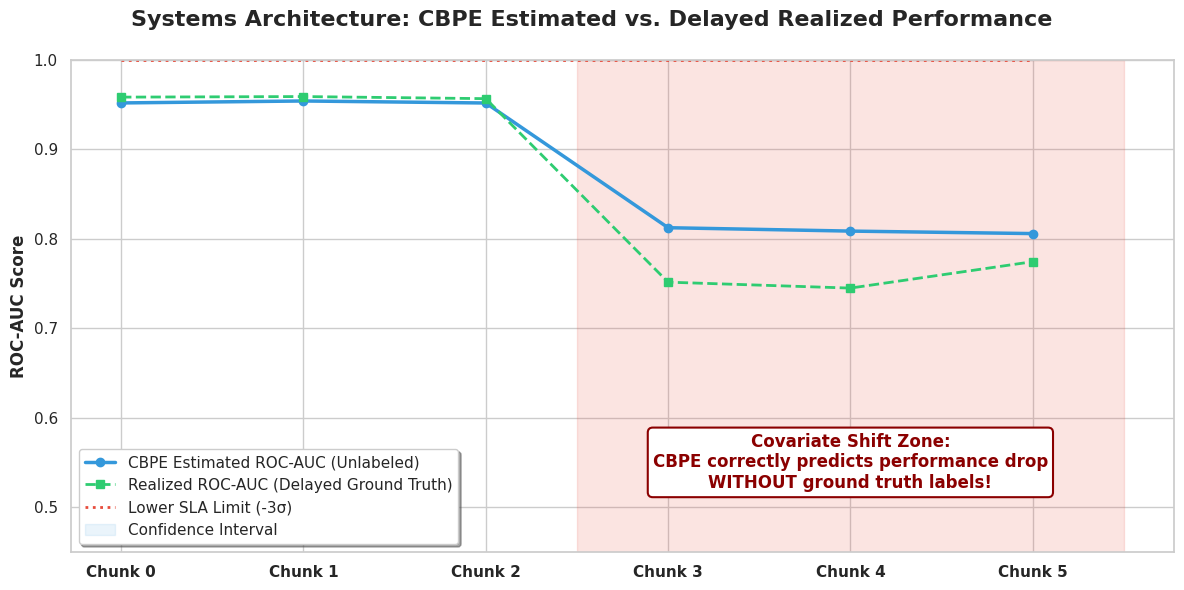

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Compute actual realized ground-truth ROC-AUC on analysis data for visual comparison
from sklearn.metrics import roc_auc_score

chunk_size = 500
realized_scores = []
chunk_labels = []

for i in range(0, len(df_analysis), chunk_size):
    chunk_y_true = y_ana[i:i+chunk_size]
    chunk_y_probs = df_analysis['y_pred_proba'].iloc[i:i+chunk_size]
    score = roc_auc_score(chunk_y_true, chunk_y_probs)
    realized_scores.append(score)
    chunk_labels.append(f"Chunk {i//chunk_size}")

# Extract CBPE Estimates & Bounds
roc_auc_analysis = roc_auc_results[
    roc_auc_results['chunk_period'] == 'analysis'
].reset_index(drop=True)

cbpe_estimates = roc_auc_analysis['roc_auc_value'].values
lower_bounds = roc_auc_analysis['roc_auc_lower_threshold'].values
upper_bounds = roc_auc_analysis['roc_auc_upper_threshold'].values

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: CBPE Estimated vs. Delayed Realized Performance", fontsize=16, fontweight='bold')

x_axis = np.arange(len(chunk_labels))

# Plot CBPE Estimated Performance
ax.plot(x_axis, cbpe_estimates, color='#3498db', marker='o', linewidth=2.5, label='CBPE Estimated ROC-AUC (Unlabeled)')

# Plot Delayed Realized Ground Truth
ax.plot(x_axis, realized_scores, color='#2ecc71', marker='s', linestyle='--', linewidth=2, label='Realized ROC-AUC (Delayed Ground Truth)')

# Plot Control Bounds
ax.plot(x_axis, lower_bounds, color='#e74c3c', linestyle=':', linewidth=2, label='Lower SLA Limit (-3σ)')
ax.fill_between(x_axis, lower_bounds, upper_bounds, color='#3498db', alpha=0.1, label='Confidence Interval')

# Highlight Drift Zone
ax.axvspan(2.5, 5.5, color='#e74c3c', alpha=0.15)
ax.text(4, 0.55, "Covariate Shift Zone:\nCBPE correctly predicts performance drop\nWITHOUT ground truth labels!", 
        ha='center', va='center', fontweight='bold', color='darkred',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1.5))

ax.set_xticks(x_axis)
ax.set_xticklabels(chunk_labels, fontweight='bold')
ax.set_ylabel("ROC-AUC Score", fontweight='bold')
ax.set_ylim(0.45, 1.0)
ax.legend(loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

*(Insight: Between Chunk 0 and Chunk 2, the model operates normally. At Chunk 3, covariate shift occurs. CBPE instantly detects the drop in estimated ROC-AUC and triggers an alert at $t=0$, whereas a team relying on delayed ground-truth labels would remain completely blind until labels arrive months later.)*

## Real-World Use Case or Analogy:

Think of Unlabeled Performance Estimation (CBPE) like **A Commercial Aircraft's Dead Reckoning Navigation System**:

* **Ground-Truth Evaluation (GPS / Visual Landmarks):** When an aircraft flies in clear weather with active GPS, it calculates its exact position relative to physical landmarks (**Ground Truth Labels**). This provides absolute certainty, but if GPS satellite signals drop out (**Ground Truth Delays**), the aircraft cannot simply stop navigating while waiting for connection recovery.
* **Unlabeled Performance Estimation / CBPE (Dead Reckoning via Accelerometers):** When GPS signals are lost, the aircraft switches to dead reckoning. By measuring air speed, heading, and acceleration vectors (**Calibrated Prediction Probabilities and Feature Distributions**), the inertial navigation computer estimates the aircraft's current velocity and position mathematically.
* **The Failure Mode (Concept Drift / Wind Shear):** If a sudden unmeasured jetstream tailwind hits the plane (**Concept Drift**, where $P(Y \mid X)$ changes without the model's knowledge), dead reckoning estimations will slowly diverge from physical reality.

By combining **Data Drift Detection (Lesson 05)** with **CBPE Unlabeled Estimation (Lesson 06)**, MLOps engineers maintain real-time visibility into production performance, raising automated flags long before delayed labels reveal business damage.